# PatchTST + Stochastic Channel Mixing on Weather

This notebook is a lightweight, presentation-ready experiment for testing whether PatchTST's strict channel independence can be relaxed with a small amount of stochastic cross-channel communication.

**Core idea**

- `mix_prob = 0.0`: pure PatchTST channel-independent baseline.
- `mix_prob = 1.0`: always apply cross-channel mixing.
- `mix_prob = 0.3 / 0.5`: stochastic hybrid — channels usually keep their own temporal identity, but sometimes communicate.

**Main question**

> Is channel independence best understood as a useful regularizer, or can we improve it with limited cross-channel mixing?

The implementation is intentionally minimal: PatchTST does the normal patch/time attention first, then one lightweight cross-channel attention layer is optionally applied before the forecasting head.

## 0. Install dependencies

Run this cell in Colab if needed. If you already have these packages, you can skip it.

## 1. Imports, seed, and device

In [10]:
import os, math, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


def set_seed(seed=2021):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # For reproducibility. You can set benchmark=True for speed after debugging.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(2021)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## 2. Configuration

Set `WEATHER_CSV_PATH` to your Weather dataset path. The notebook tries a few common paths first, but you can manually edit it.

Expected format: CSV with one timestamp/date column plus multiple numeric weather variables. The loader will automatically keep numeric columns.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATA_CSV_PATH = "/content/drive/MyDrive/p/electricity.csv"

print("DATA_CSV_PATH:", DATA_CSV_PATH)
print("Exists:", os.path.exists(DATA_CSV_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_CSV_PATH: /content/drive/MyDrive/p/electricity.csv
Exists: True


In [12]:

CFG = {
    'seq_len': 96,
    'forecast_len': 96,
    'patch_size': 16,
    'stride': 8,
    'd_model': 64,
    'nhead': 4,
    'num_layers': 3,
    'dim_feedforward': 128,
    'dropout': 0.1,

    'batch_size': 8,      # important: lower for full-channel Electricity
    'epochs': 5,
    'patience': 2,
    'learning_rate': 1e-3,

    'train_ratio': 0.7,
    'valid_ratio': 0.1,

    'step': 4,            # important: fewer sliding windows, much faster
    'seed': 2021,
}

MIX_PROBS = [0.0, 0.3, 0.5, 1.0]
OUTPUT_DIR = Path('./scm_weather_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

CFG

{'seq_len': 96,
 'forecast_len': 96,
 'patch_size': 16,
 'stride': 8,
 'd_model': 64,
 'nhead': 4,
 'num_layers': 3,
 'dim_feedforward': 128,
 'dropout': 0.1,
 'batch_size': 8,
 'epochs': 5,
 'patience': 2,
 'learning_rate': 0.001,
 'train_ratio': 0.7,
 'valid_ratio': 0.1,
 'step': 4,
 'seed': 2021}

## 3. Data loading and sliding windows

Important implementation detail: we select numeric columns only, so the timestamp column will not accidentally become a feature. Normalization uses train-set mean and standard deviation only.

In [13]:
def load_weather_csv(csv_path, max_channels=None):
    if csv_path is None or not os.path.exists(csv_path):
        raise FileNotFoundError(
            "Could not find weather.csv. Set WEATHER_CSV_PATH to the correct file path. "
            "For Colab, upload weather.csv or mount Google Drive."
        )
    df = pd.read_csv(csv_path)
    print('Raw shape:', df.shape)
    print('Columns:', list(df.columns)[:10], '...')

    # Keep numeric columns only. This safely drops date/timestamp/object columns.
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    if numeric_df.shape[1] == 0:
        raise ValueError('No numeric columns found. Check the Weather CSV format.')

    # Optional: limit channels for quick debugging.
    if max_channels is not None:
        numeric_df = numeric_df.iloc[:, :max_channels]

    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).ffill().bfill()
    print('Numeric feature shape:', numeric_df.shape)
    return numeric_df.astype(np.float32)


def create_dataloaders_from_array(data, seq_len, forecast_len, batch_size=32,
                                  train_ratio=0.7, valid_ratio=0.1, step=1):
    T_total, M = data.shape
    train_end = int(train_ratio * T_total)
    valid_end = int((train_ratio + valid_ratio) * T_total)

    train_raw = data[:train_end]
    mean = train_raw.mean(axis=0, keepdims=True)
    std = train_raw.std(axis=0, keepdims=True) + 1e-8

    # Same scaler for train/valid/test, fit on train only.
    train_data = (data[:train_end] - mean) / std
    valid_data = (data[train_end:valid_end] - mean) / std
    test_data  = (data[valid_end:] - mean) / std

    def sliding_window(d):
        X, y = [], []
        total = seq_len + forecast_len
        for i in range(0, len(d) - total + 1, step):
            X.append(d[i:i+seq_len])
            y.append(d[i+seq_len:i+total])
        if len(X) == 0:
            raise ValueError('Not enough data for the chosen seq_len + forecast_len.')
        return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

    X_train, y_train = sliding_window(train_data)
    X_valid, y_valid = sliding_window(valid_data)
    X_test, y_test = sliding_window(test_data)

    print('\nData split:')
    print(f'  total timesteps = {T_total}, variables = {M}')
    print(f'  train/valid/test timesteps = {train_end}/{valid_end-train_end}/{T_total-valid_end}')
    print('\nWindow shapes:')
    print(f'  train X={tuple(X_train.shape)}, y={tuple(y_train.shape)}')
    print(f'  valid X={tuple(X_valid.shape)}, y={tuple(y_valid.shape)}')
    print(f'  test  X={tuple(X_test.shape)}, y={tuple(y_test.shape)}')

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True, drop_last=False)
    valid_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, valid_loader, test_loader, {'mean': mean, 'std': std, 'num_variables': M}

data_df = load_weather_csv(DATA_CSV_PATH)
data = data_df.to_numpy(dtype=np.float32)

# full channels, less time
DATA_FRACTION = 1
T_use = int(len(data) * DATA_FRACTION)
data = data[:T_use]

print("Using timesteps:", data.shape[0])
print("Using channels:", data.shape[1])

train_loader, valid_loader, test_loader, data_info = create_dataloaders_from_array(
    data=data,
    seq_len=CFG['seq_len'],
    forecast_len=CFG['forecast_len'],
    batch_size=CFG['batch_size'],
    train_ratio=CFG['train_ratio'],
    valid_ratio=CFG['valid_ratio'],
    step=CFG['step'],
)
NUM_VARIABLES = data_info['num_variables']
print('NUM_VARIABLES =', NUM_VARIABLES)

Raw shape: (26304, 322)
Columns: ['date', '0', '1', '2', '3', '4', '5', '6', '7', '8'] ...
Numeric feature shape: (26304, 321)
Using timesteps: 26304
Using channels: 321

Data split:
  total timesteps = 26304, variables = 321
  train/valid/test timesteps = 18412/2631/5261

Window shapes:
  train X=(4556, 96, 321), y=(4556, 96, 321)
  valid X=(610, 96, 321), y=(610, 96, 321)
  test  X=(1268, 96, 321), y=(1268, 96, 321)
NUM_VARIABLES = 321


## 4. PatchTST baseline with explicit `encode` and `decode`

This is still a channel-independent PatchTST: `(B, L, M)` is reshaped into `(B*M, L)`, so each channel is processed as a separate univariate series with shared weights.

The key change from a simple implementation is that we expose `encode()` and `decode()` so the hybrid model can insert cross-channel mixing between them.

In [14]:
class RevIN(nn.Module):
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(1))
        self.affine_bias = nn.Parameter(torch.zeros(1))
        self.mean = None
        self.std = None

    def normalize(self, x):
        # x: (B*M, L)
        self.mean = x.mean(dim=-1, keepdim=True)
        self.std = x.std(dim=-1, keepdim=True) + self.eps
        x = (x - self.mean) / self.std
        return x * self.affine_weight + self.affine_bias

    def denormalize(self, x):
        # x: (B*M, T)
        return ((x - self.affine_bias) / (self.affine_weight + self.eps)) * self.std + self.mean


class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, d_model, num_patches):
        super().__init__()
        self.Wp = nn.Linear(patch_size, d_model, bias=False)
        self.Wpos = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)

    def forward(self, x_p):
        # x_p: (B*M, num_patches, patch_size)
        return self.Wp(x_p) + self.Wpos


class BatchNormTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff1 = nn.Linear(d_model, dim_feedforward)
        self.ff2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm1d(d_model)
        self.bn2 = nn.BatchNorm1d(d_model)

    def forward(self, x):
        # x: (B*M, num_patches, d_model)
        attn_out, _ = self.self_attn(x, x, x, need_weights=False)
        x = x + self.dropout(attn_out)
        x = self.bn1(x.transpose(1, 2)).transpose(1, 2)

        ff_out = self.ff2(self.dropout(F.gelu(self.ff1(x))))
        x = x + self.dropout(ff_out)
        x = self.bn2(x.transpose(1, 2)).transpose(1, 2)
        return x


class PatchTST_CI(nn.Module):
    def __init__(self, seq_len, forecast_len, patch_size, stride,
                 d_model, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.forecast_len = forecast_len
        self.patch_size = patch_size
        self.stride = stride
        self.d_model = d_model
        # +1 because we pad at the end by repeating the last value stride times.
        self.num_patches = math.floor((seq_len - patch_size) / stride) + 2

        self.revin = RevIN()
        self.patch_embed = PatchEmbedding(patch_size, d_model, self.num_patches)
        self.encoder_layers = nn.ModuleList([
            BatchNormTransformerLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.flatten = nn.Flatten(start_dim=1)
        self.linear_head = nn.Linear(self.num_patches * d_model, forecast_len)

    def _make_patches(self, x):
        # x: (B*M, L)
        # Replicate-pad at the end by stride steps, matching PatchTST-style padding.
        x = F.pad(x, (0, self.stride), mode='replicate')
        patches = x.unfold(dimension=-1, size=self.patch_size, step=self.stride)
        # patches: (B*M, num_patches, patch_size)
        return patches

    def encode(self, x):
        # x: (B, L, M)
        B, L, M = x.shape
        x_uni = x.permute(0, 2, 1).reshape(B * M, L)
        x_uni = self.revin.normalize(x_uni)
        z = self._make_patches(x_uni)
        z = self.patch_embed(z)
        for layer in self.encoder_layers:
            z = layer(z)
        return z, B, M

    def decode(self, z, B, M):
        # z: (B*M, num_patches, d_model)
        out = self.linear_head(self.flatten(z))
        out = self.revin.denormalize(out)
        return out.reshape(B, M, self.forecast_len)

    def forward(self, x):
        z, B, M = self.encode(x)
        return self.decode(z, B, M)

## 5. Lightweight stochastic cross-channel mixing

The cross-channel layer attends across variables at each patch position:

- Input from PatchTST encoder: `(B*M, P, D)`
- Reshape to `(B*P, M, D)`
- Apply channel-axis attention
- Reshape back to `(B*M, P, D)`

During training, the layer is applied with probability `mix_prob`. During evaluation, we use the dropout-style expected path:

```python
z_eval = z + mix_prob * (mixed_z - z)
```

In [15]:
class CrossChannelMixingLayer(nn.Module):
    def __init__(self, d_model, nhead=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, z, B, M):
        # z: (B*M, P, D)
        BM, P, D = z.shape
        assert BM == B * M, f'Expected BM={B*M}, got {BM}'

        # (B*M, P, D) -> (B, M, P, D) -> (B*P, M, D)
        z_chan = z.reshape(B, M, P, D).permute(0, 2, 1, 3).reshape(B * P, M, D)
        attn_out, _ = self.attn(z_chan, z_chan, z_chan, need_weights=False)
        z_chan = self.norm(z_chan + self.dropout(attn_out))

        # Back: (B*P, M, D) -> (B*M, P, D)
        z_out = z_chan.reshape(B, P, M, D).permute(0, 2, 1, 3).reshape(B * M, P, D)
        return z_out


class PatchTST_SCM(nn.Module):
    """PatchTST + one lightweight Stochastic Channel Mixing layer."""
    def __init__(self, seq_len, forecast_len, patch_size, stride,
                 d_model, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1,
                 mix_prob=0.0, mix_heads=4):
        super().__init__()
        self.mix_prob = float(mix_prob)
        self.backbone = PatchTST_CI(
            seq_len=seq_len,
            forecast_len=forecast_len,
            patch_size=patch_size,
            stride=stride,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.cross_mixer = CrossChannelMixingLayer(d_model=d_model, nhead=mix_heads, dropout=dropout)

    def forward(self, x):
        z, B, M = self.backbone.encode(x)

        if self.mix_prob <= 0:
            z_out = z
        elif self.training:
            # Stochastic path: sometimes communicate, sometimes stay pure CI.
            if torch.rand((), device=z.device).item() < self.mix_prob:
                z_out = self.cross_mixer(z, B, M)
            else:
                z_out = z
        else:
            # Deterministic expected path, analogous to dropout scaling.
            z_mix = self.cross_mixer(z, B, M)
            z_out = z + self.mix_prob * (z_mix - z)

        return self.backbone.decode(z_out, B, M)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Shape sanity check on one batch
x0, y0 = next(iter(train_loader))
mini_model = PatchTST_SCM(**{k: CFG[k] for k in ['seq_len','forecast_len','patch_size','stride','d_model','nhead','num_layers','dim_feedforward','dropout']}, mix_prob=0.5).to(device)
with torch.no_grad():
    out0 = mini_model(x0[:2].to(device))
print('Input shape:', tuple(x0[:2].shape))
print('Output shape:', tuple(out0.shape), 'Expected:', (2, NUM_VARIABLES, CFG['forecast_len']))
print('Params:', count_parameters(mini_model))
del mini_model
if device == 'cuda':
    torch.cuda.empty_cache()

Input shape: (2, 96, 321)
Output shape: (2, 321, 96) Expected: (2, 321, 96)
Params: (192802, 192802)


## 6. Training and evaluation utilities

The target `y` from the dataloader has shape `(B, forecast_len, M)`, while the model outputs `(B, M, forecast_len)`, so we permute the target before computing MSE.

In [16]:
def evaluate(model, loader, device, return_predictions=False):
    model.eval()
    criterion = nn.MSELoss()
    total_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.permute(0, 2, 1).to(device)  # (B, M, T)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)
            if return_predictions:
                preds.append(pred.detach().cpu())
                trues.append(yb.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    if return_predictions:
        return avg_loss, torch.cat(preds, dim=0).numpy(), torch.cat(trues, dim=0).numpy()
    return avg_loss


def train_one_model(model, train_loader, valid_loader, device, epochs=8, lr=1e-3, patience=3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {'train_loss': [], 'valid_loss': []}

    best_valid = float('inf')
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for xb, yb in pbar:
            xb = xb.to(device)
            yb = yb.permute(0, 2, 1).to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running += loss.item() * xb.size(0)
            pbar.set_postfix({'train_mse': f'{loss.item():.4f}'})

        train_loss = running / len(train_loader.dataset)
        valid_loss = evaluate(model, valid_loader, device)
        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)
        print(f'Epoch {epoch:02d}: train={train_loss:.6f}, valid={valid_loss:.6f}')

        if valid_loss < best_valid - 1e-7:
            best_valid = valid_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f'Early stopping at epoch {epoch}. Best valid={best_valid:.6f}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_valid

## 7. Run the stochastic mixing probability sweep

For a faster smoke test, set `CFG['epochs'] = 2` and `MIX_PROBS = [0.0, 0.5]`. For the presentation run, use at least `[0.0, 0.3, 0.5, 1.0]`.

In [17]:
CFG["epochs"] = 20
CFG["patience"] = 3
CFG["step"] = 4

MIX_PROBS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

In [18]:
results = []
histories = {}
models = {}

base_kwargs = {k: CFG[k] for k in ['seq_len','forecast_len','patch_size','stride','d_model','nhead','num_layers','dim_feedforward','dropout']}

for p in MIX_PROBS:
    print('\n' + '='*80)
    print(f'Training PatchTST_SCM with mix_prob = {p}')
    print('='*80)
    set_seed(CFG['seed'])  # Same initialization seed for cleaner comparison.

    model = PatchTST_SCM(**base_kwargs, mix_prob=p, mix_heads=CFG['nhead'])
    total_params, trainable_params = count_parameters(model)
    print(f'Parameters: total={total_params:,}, trainable={trainable_params:,}')

    start = time.time()
    model, history, best_valid = train_one_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        device=device,
        epochs=CFG['epochs'],
        lr=CFG['learning_rate'],
        patience=CFG['patience'],
    )
    elapsed_min = (time.time() - start) / 60
    test_mse, preds, targets = evaluate(model, test_loader, device, return_predictions=True)

    row = {
        'mix_prob': p,
        'best_valid_mse': best_valid,
        'test_mse': test_mse,
        'test_rmse': float(np.sqrt(test_mse)),
        'params': total_params,
        'elapsed_min': elapsed_min,
    }
    print('RESULT:', row)
    results.append(row)
    histories[p] = history
    models[p] = model.cpu()

    # Save predictions only for the best/final inspection if needed.
    np.savez_compressed(OUTPUT_DIR / f'preds_mix_{str(p).replace(".", "p")}.npz', preds=preds, targets=targets)

    if device == 'cuda':
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results).sort_values('mix_prob')
results_df.to_csv(OUTPUT_DIR / 'results_scm_weather.csv', index=False)
results_df


Training PatchTST_SCM with mix_prob = 0.0
Parameters: total=192,802, trainable=192,802


Epoch 01: train=0.214757, valid=0.172112


Epoch 02: train=0.191031, valid=0.165577


Epoch 03: train=0.184763, valid=0.157806


Epoch 04: train=0.180377, valid=0.156209


...

Epoch 17: train=0.141450, valid=0.137765


Epoch 18: train=0.140681, valid=0.136152


Epoch 19: train=0.140258, valid=0.134641


Epoch 20: train=0.139089, valid=0.136499
RESULT: {'mix_prob': 1.0, 'best_valid_mse': 0.13464148232682807, 'test_mse': 0.1861850288858173, 'test_rmse': 0.43149163246326955, 'params': 192802, 'elapsed_min': 15.212653191884359}


,mix_prob,best_valid_mse,test_mse,test_rmse,params,elapsed_min
0,0.0,0.144212,0.203732,0.451367,192802,9.279948
1,0.1,0.142189,0.210878,0.459214,192802,11.504002
2,0.2,0.143916,0.197667,0.444597,192802,9.539404
3,0.3,0.139934,0.200658,0.447949,192802,12.346755
4,0.4,0.138428,0.198371,0.445389,192802,12.858617
5,0.5,0.138491,0.194526,0.441051,192802,13.276213
6,0.6,0.137129,0.191605,0.437728,192802,13.627729
7,0.7,0.138237,0.188546,0.434219,192802,11.976195
8,0.8,0.136778,0.189949,0.435832,192802,12.282748
9,0.9,0.137273,0.184977,0.430089,192802,12.563190


## 8. Plot results

The most important plot is `mix_prob` versus test MSE. A U-shape would support the stochastic hybrid intuition; a monotone or flat curve is still interpretable.

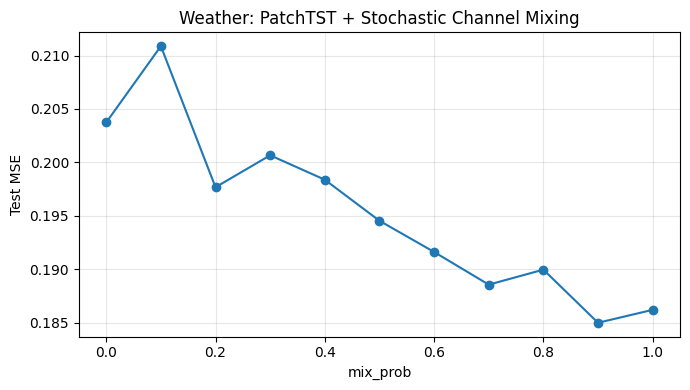

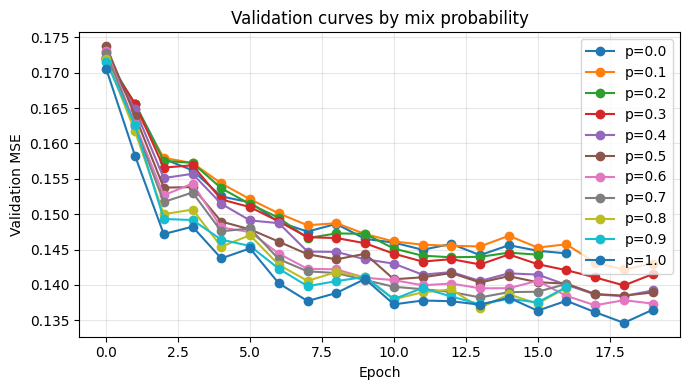

Saved outputs to: /content/scm_weather_outputs
    mix_prob  best_valid_mse  test_mse  test_rmse  params  elapsed_min
0        0.0        0.144212  0.203732   0.451367  192802     9.279948
1        0.1        0.142189  0.210878   0.459214  192802    11.504002
2        0.2        0.143916  0.197667   0.444597  192802     9.539404
3        0.3        0.139934  0.200658   0.447949  192802    12.346755
4        0.4        0.138428  0.198371   0.445389  192802    12.858617
5        0.5        0.138491  0.194526   0.441051  192802    13.276213
6        0.6        0.137129  0.191605   0.437728  192802    13.627729
7        0.7        0.138237  0.188546   0.434219  192802    11.976195
8        0.8        0.136778  0.189949   0.435832  192802    12.282748
9        0.9        0.137273  0.184977   0.430089  192802    12.563190
10       1.0        0.134641  0.186185   0.431492  192802    15.212653


In [19]:
plt.figure(figsize=(7, 4))
plt.plot(results_df['mix_prob'], results_df['test_mse'], marker='o')
plt.xlabel('mix_prob')
plt.ylabel('Test MSE')
plt.title('Weather: PatchTST + Stochastic Channel Mixing')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mix_prob_vs_test_mse.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
for p, hist in histories.items():
    plt.plot(hist['valid_loss'], marker='o', label=f'p={p}')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.title('Validation curves by mix probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validation_curves.png', dpi=200)
plt.show()

print('Saved outputs to:', OUTPUT_DIR.resolve())
print(results_df)

## 9. Forecast visualization for the best model

This helps make the result more intuitive in the presentation. It plots one test sample for a few variables.

Best mix_prob by test MSE: 0.9


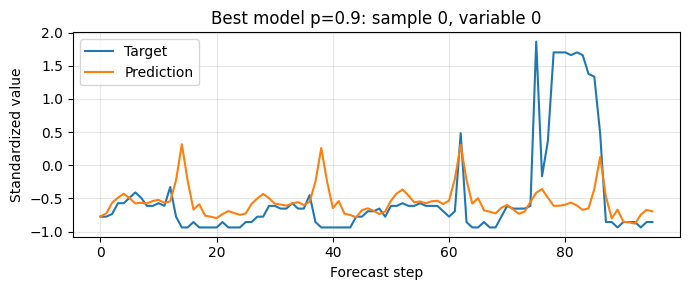

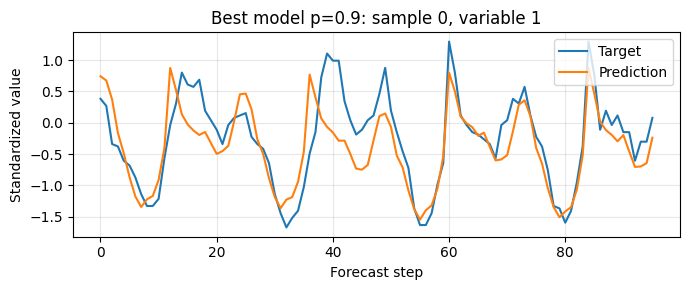

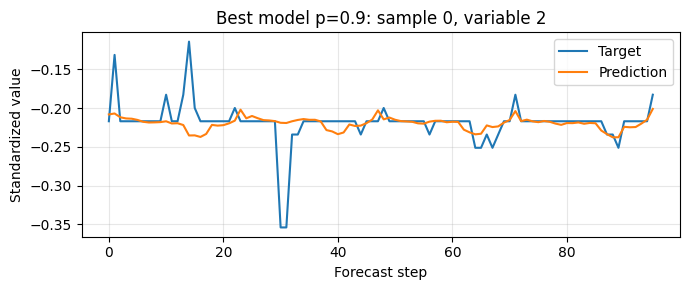

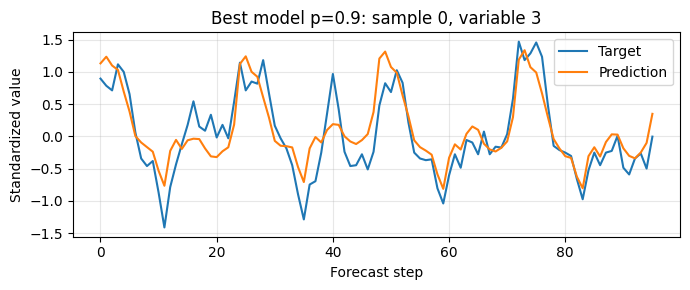

In [20]:
best_row = results_df.loc[results_df['test_mse'].idxmin()]
best_p = float(best_row['mix_prob'])
print('Best mix_prob by test MSE:', best_p)

# Load predictions saved during the sweep.
pred_file = OUTPUT_DIR / f'preds_mix_{str(best_p).replace(".", "p")}.npz'
arr = np.load(pred_file)
preds = arr['preds']       # (N, M, T)
targets = arr['targets']   # (N, M, T)

sample_idx = 0
num_vars_to_plot = min(4, preds.shape[1])
for var_idx in range(num_vars_to_plot):
    plt.figure(figsize=(7, 3))
    plt.plot(targets[sample_idx, var_idx], label='Target')
    plt.plot(preds[sample_idx, var_idx], label='Prediction')
    plt.xlabel('Forecast step')
    plt.ylabel('Standardized value')
    plt.title(f'Best model p={best_p}: sample {sample_idx}, variable {var_idx}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'forecast_best_p_{best_p}_var_{var_idx}.png', dpi=200)
    plt.show()

## 10. Presentation-ready interpretation template

Use the branch that matches your actual result.

### Case A: middle `mix_prob` wins

> The best model occurs at an intermediate mixing probability, which supports our hypothesis that pure channel independence and full channel mixing are two extremes. Stochastic mixing allows the model to preserve channel-specific temporal patterns while occasionally reinforcing shared cross-channel structure.

### Case B: `mix_prob = 0.0` wins

> Pure PatchTST remains strongest on Weather in our current setup. This supports the interpretation that channel independence is a powerful architectural regularizer. The additional cross-channel flexibility did not compensate for the risk of overfitting or noisy channel interactions.

### Case C: `mix_prob = 1.0` wins

> Always-on cross-channel mixing performs best, suggesting that Weather contains useful physical relationships across variables. This indicates that pure channel independence may be too restrictive for correlated multivariate systems.

### Safe final sentence

> Overall, our experiment reframes channel independence not as a fixed truth, but as a point on a spectrum between regularization and cross-channel expressiveness.

## 11. Save experiment metadata

In [21]:
metadata = {
    'cfg': CFG,
    'mix_probs': MIX_PROBS,
    'weather_csv_path': DATA_CSV_PATH,
    'num_variables': int(NUM_VARIABLES),
    'results': results_df.to_dict(orient='records'),
}
with open(OUTPUT_DIR / 'experiment_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Metadata saved to:', OUTPUT_DIR / 'experiment_metadata.json')
print('Results CSV:', OUTPUT_DIR / 'results_scm_weather.csv')
print('Main plot:', OUTPUT_DIR / 'mix_prob_vs_test_mse.png')

Metadata saved to: scm_weather_outputs/experiment_metadata.json
Results CSV: scm_weather_outputs/results_scm_weather.csv
Main plot: scm_weather_outputs/mix_prob_vs_test_mse.png
